<a href="https://colab.research.google.com/github/chaturvedulakashyap-source/Kuramoto-Oscillator/blob/main/Kuramoto_Oscillator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

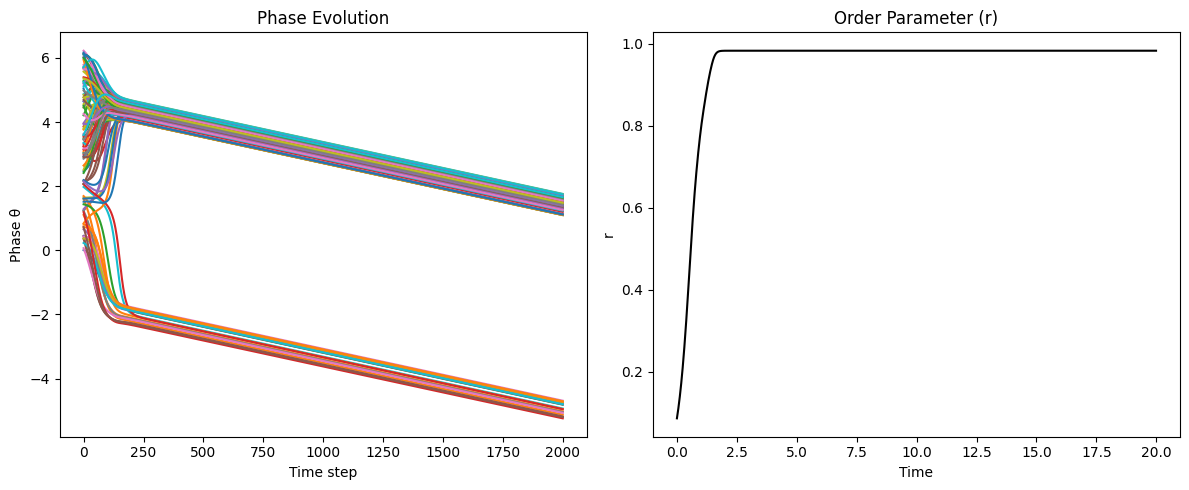

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 100                 # number of oscillators
K = 6.0                 # coupling strength
T = 20                  # total time
dt = 0.01               # time step
steps = int(T/dt)

# Natural frequencies (omega_i)
omega = np.random.normal(0, 1, N)

# Initial phases (theta_i)
theta = np.random.uniform(0, 2*np.pi, N)

# Storage
theta_history = np.zeros((steps, N))
r_history = np.zeros(steps)

# Simulation loop
for t in range(steps):
    theta_history[t] = theta

    # Compute order parameter r
    complex_order = np.mean(np.exp(1j * theta))
    r = np.abs(complex_order)
    r_history[t] = r

    # Kuramoto update
    theta_dot = np.zeros(N)
    for i in range(N):
        interaction = np.sum(np.sin(theta - theta[i]))
        theta_dot[i] = omega[i] + (K/N) * interaction

    theta += dt * theta_dot

# ---- Plot results ----
plt.figure(figsize=(12,5))

# Phase evolution
plt.subplot(1,2,1)
plt.plot(theta_history)
plt.title("Phase Evolution")
plt.xlabel("Time step")
plt.ylabel("Phase θ")

# Order parameter
plt.subplot(1,2,2)
plt.plot(np.arange(steps)*dt, r_history, 'k')
plt.title("Order Parameter (r)")
plt.xlabel("Time")
plt.ylabel("r")

plt.tight_layout()
plt.show()